In [2]:
import pandas as pd

p22 = pd.read_csv('../data/processed_22.csv')
p23 = pd.read_csv('../data/processed_23.csv')
p24 = pd.read_csv('../data/processed_24.csv')
p25 = pd.read_csv('../data/processed_25.csv')
combined = pd.concat([p22, p23, p24, p25], ignore_index=True)
# combined.to_csv('./data/processed_all.csv', index=False)
# print("Combined dataset saved to './data/processed_all.csv'")

combined.head()

,date,roiCount,ml_analyzed,ROI_per_ml,Lpoly_expected,Lpoly_expected_ml,Pmicans_expected,Pmicans_expected_ml,Area,B180,...,HOG79,HOG80,HOG81,Area_over_PerimeterSquared,Area_over_Perimeter,H90_over_Hflip,H90_over_H180,Hflip_over_H180,summedConvexPerimeter_over_Perimeter,rotated_BoundingBox_solidity
0,20221005,213.288889,4.893444,43.586658,22.935411,4.686967,13.751131,2.810113,11974.557229,0.928882,...,0.611308,0.095367,0.274156,0.041771,22.170160,1.266836,1.313910,1.068659,0.791211,0.631238
1,20221006,162.452830,4.894208,33.192877,13.319224,2.721426,12.074286,2.467056,11823.709733,0.934288,...,0.611941,0.096601,0.273971,0.045117,22.886624,1.297578,1.357131,1.074133,0.813061,0.646811
2,20221007,169.980000,4.872780,34.883578,5.074974,1.041495,43.708223,8.969874,10610.368513,0.935896,...,0.620756,0.098899,0.275299,0.046589,21.911387,1.437337,1.431526,1.023397,0.827414,0.642660
3,20221008,336.345455,4.859036,69.220609,9.665164,1.989111,114.070859,23.476025,9582.249814,0.934213,...,0.630919,0.098680,0.271302,0.046811,20.918614,1.501327,1.517644,1.064838,0.834406,0.635710
4,20221009,561.684211,4.786596,117.345218,47.861245,9.999014,67.474689,14.096590,10906.921467,0.930262,...,0.619425,0.094373,0.272369,0.043465,21.595006,1.312042,1.364307,1.068552,0.803011,0.634383


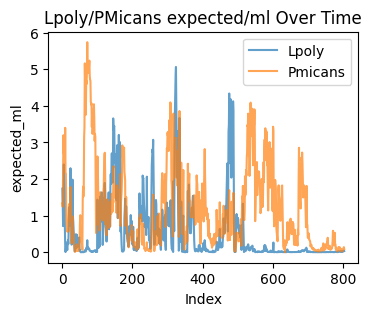

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4, 3))

y = combined['Lpoly_expected_ml'].copy()
y_log = np.log1p(y)
b = combined['Pmicans_expected_ml'].copy()
b_log = np.log1p(b)

plt.plot(y_log, label="Lpoly", alpha=0.7)
plt.plot(b_log, label="Pmicans", alpha=0.7)
plt.legend()

# combined['Lpoly_expected_ml'].plot(kind='line')
plt.title('Lpoly/PMicans expected/ml Over Time')
plt.xlabel('Index')
plt.ylabel('expected_ml')

plt.show()

# log transformation seems good..
# I'm sure there is some implications to consider when using log transformation (ln(1+x))
# but idk them cause I don't remember them lol

Trivial model
- predict tomorrow = today
    - y_pred[t+1] = y[t]

Trivial RMSE: 0.4255365436742989
Trivial Correlation: 0.8776869022542403


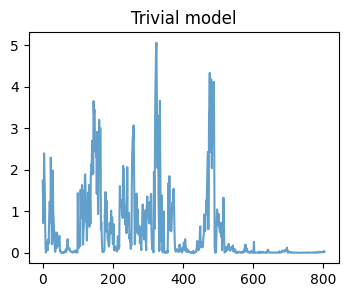

In [49]:
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

y = combined['Lpoly_expected_ml'].copy()
y_log = np.log1p(y)

# tmrws value
y_true = y_log[1:]
# predict todays value as tmrws value
y_pred = y_log[:-1]

rmse = root_mean_squared_error(y_true, y_pred)
print("Trivial RMSE:", rmse)
correlation = np.corrcoef(y_true, y_pred)[0, 1]
print("Trivial Correlation:", correlation)

plt.figure(figsize=(4, 3))
plt.plot(y_pred, label="Predicted (trivial)", alpha=0.7)
plt.title("Trivial model")
plt.show()

^ This shows very strong day to day correlation. 
- RMSE idk it's good?

Trivial Model 2
- Always predict the mean (.5/ml)

In [60]:
y = combined['Lpoly_expected_ml'].values
y_log = np.log1p(y)

y_true = y_log[1:]
mean_val = y_log.mean()
y_pred = np.full(len(y_true), np.mean(y_log))
rmse = root_mean_squared_error(y_true, y_pred)
print("Mean RMSE:", rmse)   
# correlation = np.corrcoef(y_true, y_pred)[0, 1]
print("Mean Correlation:", 0)

Mean RMSE: 0.8599219877539703
Mean Correlation: 0


PCA and ridge regression have been ommited since not sure if it's correct..

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

a = [ "date", "ROI_per_ml", "Lpoly_expected", "Lpoly_expected_ml",
"Area",	
"Biovolume", "MajorAxisLength", "MinorAxisLength",
"Perimeter", "Orientation", "Eccentricity",
"Solidity", "texture_uniformity", "texture_smoothness",
"texture_average_gray_level", "texture_entropy",
"texture_average_contrast", "H90",
"H180", "Hflip", "Extent", "EquivDiameter",
"ConvexArea", "ConvexPerimeter" ]

foo = combined[a]
foo.head()

# set of features determined by paper ^

# ridge regression of 20 features
X = foo.drop(columns=[ "date", "ROI_per_ml", "Lpoly_expected", "Lpoly_expected_ml" ])
y = foo["Lpoly_expected_ml"].values
y_log = np.log1p(y)

X = X.iloc[:-1].reset_index(drop=True)
y_log = y_log[1:]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y_log)

y_pred = ridge.predict(X_scaled)

rmse = root_mean_squared_error(y_log, y_pred)
corr = np.corrcoef(y_log, y_pred)[0, 1]

print("Ridge RMSE:", rmse)
print("Ridge Correlation:", corr)

Ridge RMSE: 0.6173670010742215
Ridge Correlation: 0.6961804583296287


In [ ]:
env = pd.read_csv('./data/environment_all.csv')
env.head()

# there's a lot of missing data in env not really sure what to do...

,date,mass_concentration_of_chlorophyll_in_sea_water_ctd,sea_water_electrical_conductivity_ctd,mass_concentration_of_oxygen_in_sea_water_seaphox,mole_concentration_of_dissolved_molecular_oxygen_in_sea_water_seaphox,fluorescent_dissolved_organic_matter_eco,fractional_saturation_of_oxygen_in_sea_water_seaphox,sea_water_ph_reported_on_total_scale_seaphox_external,sea_water_practical_salinity_ctd,sea_water_sigma_t_ctd,sea_water_pressure_ctd,sea_water_turbidity_eco,sea_water_temperature_ctd,wind_speed_ms,wind_dir_deg,wind_gust_ms,air_temp_c,baro_mb,waterlevel_predicted_m,waterlevel_verified_m
0,20221001,28.717,47.012,0.071,2.199,NaN,0.952,8.678,33.406,23.250,3.475,NaN,21.054,2.066667,216.458333,3.166667,19.250000,1010.879167,0.904167,0.955167
1,20221002,37.439,46.926,0.091,2.840,NaN,1.235,8.670,33.418,23.294,3.454,NaN,20.957,2.287500,217.166667,3.050000,19.841667,1012.595833,0.883958,0.927333
2,20221003,46.564,45.266,0.262,8.178,NaN,3.444,8.653,33.377,23.694,3.456,NaN,19.307,2.279167,235.750000,3.087500,20.229167,1014.079167,0.866542,0.899667
3,20221004,55.428,43.889,0.305,9.530,NaN,3.931,8.648,33.317,23.990,3.439,NaN,17.962,1.491667,172.500000,2.050000,19.504167,1013.445833,0.856833,0.903083
4,20221005,62.660,44.128,0.139,4.353,NaN,1.811,8.700,33.304,23.917,3.427,NaN,18.227,1.645833,238.833333,2.045833,18.700000,1013.991667,0.857458,0.892917
